# Proyecto Tutorial de Mejorando Algoritmos

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from xgboost import XGBClassifier


# Para evitar warnings innecesarios en el notebook
import warnings
warnings.filterwarnings("ignore")

In [30]:
# Cargar dataset
url = "https://breathecode.herokuapp.com/asset/internal-link?id=930&path=diabetes.csv"
df = pd.read_csv(url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Separamos variables

In [31]:
# variables predictoras
X = df.drop("Outcome", axis=1)

# variable objetivo
y = df["Outcome"]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
# Verficamos si la variable objetivo está desbalanceada
print(y.value_counts())
print(y.value_counts(normalize=True))

Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


# Paso 2: Construir el modelo XGBoost

In [34]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [35]:
# Generamos las precciones de clases

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:,1]

### Analizamos el modelo base

In [36]:
print(f"""
Accuracy: {accuracy_score(y_test, y_pred):.3f}
Precision: {precision_score(y_test, y_pred):.3f}
Recall: {recall_score(y_test, y_pred):.3f}
F1 Score: {f1_score(y_test, y_pred):.3f}
ROC AUC: {roc_auc_score(y_test, y_prob):.3f}
""")
print("--------------------------------------------------------")
print(classification_report(y_test, y_pred))


Accuracy: 0.747
Precision: 0.642
Recall: 0.630
F1 Score: 0.636
ROC AUC: 0.828

--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       100
           1       0.64      0.63      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



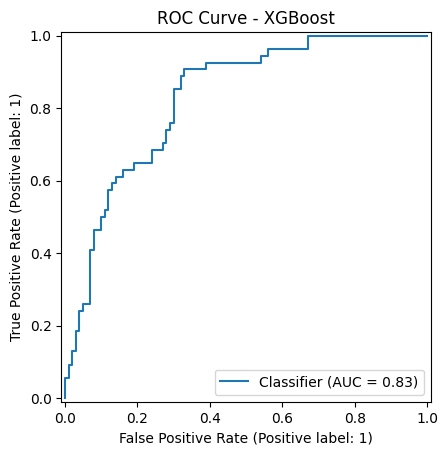

In [37]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("ROC Curve - XGBoost")
plt.show()

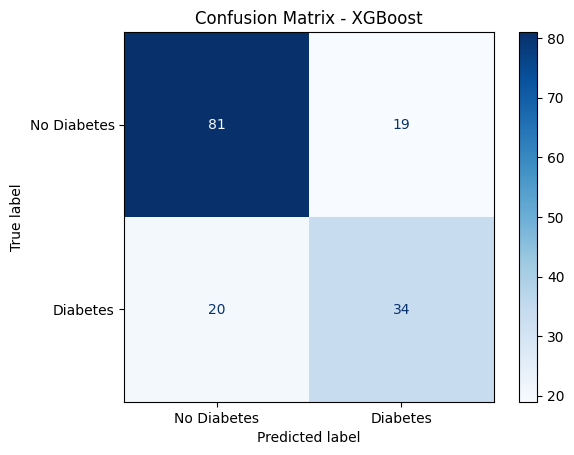

In [38]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes","Diabetes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.show()

## Probamos Hiperparámetros

In [39]:
# Definimos Modelo Base
xgb_model = XGBClassifier(
    random_state=42
)

# Definimos los parámetros a usar 
param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1],
    "colsample_bytree": [0.7, 0.8, 1]
}

# Configuramos el RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=20,        
    scoring="accuracy",
    cv=5,
    random_state=42,
    n_jobs=-1
)

### Entrenamos el Modelo Optimizado

In [40]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be u

### Vemos los Mejores parámetros

In [41]:
# Generamos un diccionario con toda la información de los modelos evaluados.
results_df = pd.DataFrame(random_search.cv_results_)
results_df.columns

Index(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time',
       'param_subsample', 'param_n_estimators', 'param_max_depth',
       'param_learning_rate', 'param_colsample_bytree', 'params',
       'split0_test_score', 'split1_test_score', 'split2_test_score',
       'split3_test_score', 'split4_test_score', 'mean_test_score',
       'std_test_score', 'rank_test_score'],
      dtype='str')

In [42]:
# Seleccionar solo las columnas importantes
results_df = results_df[
    [
        "param_n_estimators",
        "param_max_depth",
        "param_learning_rate",
        "param_subsample",
        "param_colsample_bytree",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
]

# Ordenar de mejor a peor modelo
results_df = results_df.sort_values(
    by="mean_test_score",
    ascending=False
)

results_df.head(10)


,param_n_estimators,param_max_depth,param_learning_rate,param_subsample,param_colsample_bytree,mean_test_score,std_test_score,rank_test_score
18,400,3,0.01,0.7,0.7,0.780155,0.028447,1
9,200,3,0.01,0.8,0.8,0.772038,0.024243,2
10,400,3,0.01,0.7,0.8,0.772011,0.032760,3
7,400,3,0.01,0.8,0.8,0.768786,0.034011,4
13,400,6,0.01,0.8,1.0,0.767133,0.044549,5
8,200,3,0.05,0.7,0.8,0.760562,0.034505,6
3,300,5,0.01,0.7,0.7,0.759003,0.024036,7
14,200,6,0.01,0.7,0.7,0.757364,0.018396,8
17,100,5,0.05,0.7,0.7,0.755698,0.024673,9
0,200,6,0.10,0.8,1.0,0.750806,0.036622,10


In [43]:
# Función más resumida
print("Mejores parámetros:")
print(random_search.best_params_)

Mejores parámetros:
{'subsample': 0.7, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


### Definimos el mejor modelo

In [44]:
best_xgb = random_search.best_estimator_

In [45]:
y_pred = best_xgb.predict(X_test)
y_prob = best_xgb.predict_proba(X_test)[:,1]

## Evaluar el modelo optimizado

In [46]:
print(f"""
Accuracy: {accuracy_score(y_test, y_pred):.3f}
Precision: {precision_score(y_test, y_pred):.3f}
Recall: {recall_score(y_test, y_pred):.3f}
F1 Score: {f1_score(y_test, y_pred):.3f}
ROC AUC: {roc_auc_score(y_test, y_prob):.3f}
""")
print("--------------------------------------------------------")
print(classification_report(y_test, y_pred))


Accuracy: 0.760
Precision: 0.681
Recall: 0.593
F1 Score: 0.634
ROC AUC: 0.824

--------------------------------------------------------
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154



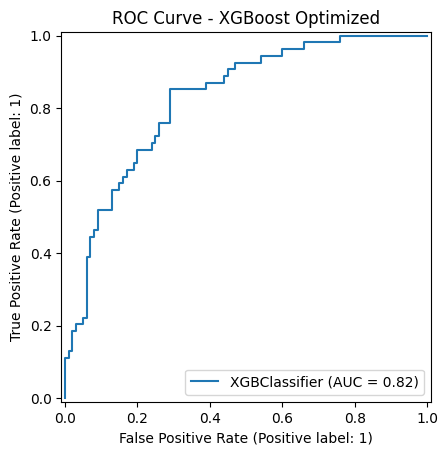

In [47]:
RocCurveDisplay.from_estimator(best_xgb, X_test, y_test)

plt.title("ROC Curve - XGBoost Optimized")
plt.show()

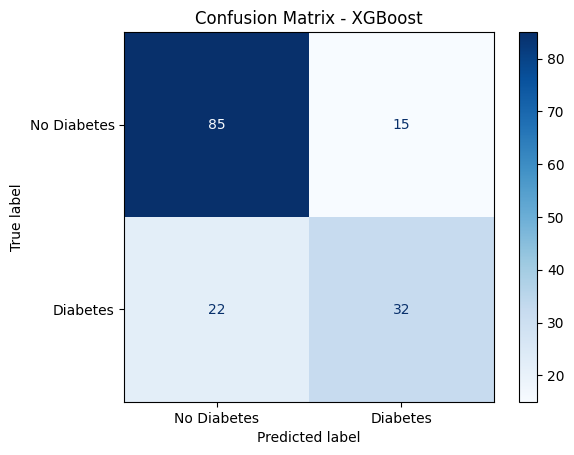

In [48]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes","Diabetes"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - XGBoost")
plt.show()

# Evaluamos diferentes modelos y visualizar el mejor

### Extraemos los mejores resultados de cada métrica de evaluación de cada modelo

In [57]:
results = {
    "Model": ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy": [0.727, 0.747, 0.760],
    "Precision": [0.643, 0.683, 0.681],
    "Recall": [0.500, 0.519, 0.593],
    "F1 Score": [0.563, 0.589, 0.634],
    "ROC AUC": [0.813, 0.813, 0.824]
}

results_df_model = pd.DataFrame(results)

results_df_model.sort_values("Accuracy", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,XGBoost,0.760,0.681,0.593,0.634,0.824
1,Random Forest,0.747,0.683,0.519,0.589,0.813
0,Decision Tree,0.727,0.643,0.500,0.563,0.813


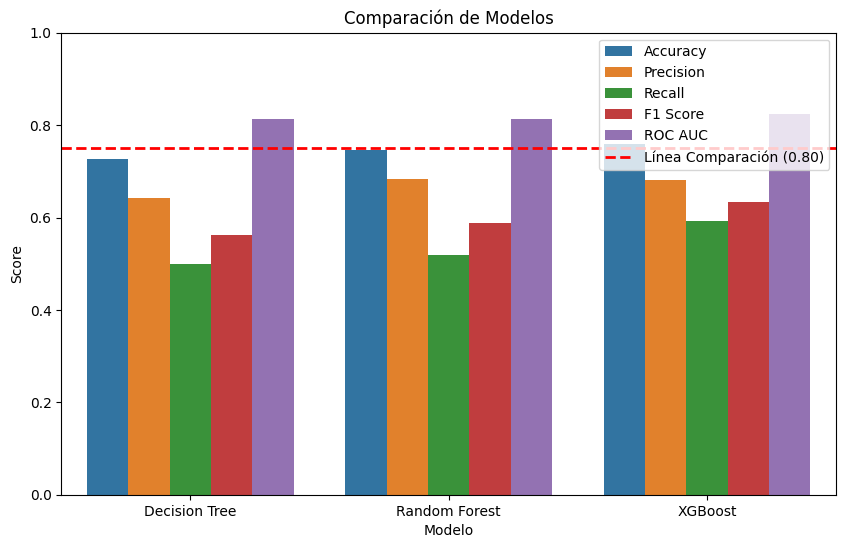

In [58]:
results_melted = results_df_model.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.axhline(
    y=0.75,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Línea Comparación (0.80)"
)

plt.title("Comparación de Modelos")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.ylim(0,1)

plt.legend()

plt.show()

# Conclusión:

En Base a la exigencia de los ejercicios de entrenar los diferentes modelos para mejorar el "accuracy":

Vemos que el mejor modelo sería XGBoost, superando en prácticamente todas las evaluaciónes de métricas, específicamente en "accuracy" con un 0.760.
Cabe destacar que para esta base de datos, lo mejor era optimizar el "Recall" dado que es una data con fines médicos y posiblemente podríamos obtener mejores resultados en la detección de pacientes Con o Sin Diabetes.


## Guardamos Modelo

In [60]:
import joblib

joblib.dump(best_xgb, "../models/xgboost_model.pkl")

['../models/xgboost_model.pkl']